# Кластеризация

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm import tqdm
import os
import sys

sys.path.append('..')
from utils import dunn_index, compute_gap_statistic, get_cluster_report, get_centroid_examples

RANDOM_STATE = 42

Загрузка данных

In [3]:
df = pd.read_csv("../data/split/02_text_for_vectorization.csv")
X_tfidf = np.load("../data/embeddings/tfidf.npy", allow_pickle=True)

if isinstance(X_tfidf, np.ndarray) and X_tfidf.dtype == object:
    X_tfidf = X_tfidf.item()

Предобработка

SVD

In [4]:
svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
X_tfidf_reduced = svd.fit_transform(X_tfidf)

Нормализация

In [5]:
X_tfidf_norm = normalize(X_tfidf_reduced)

k-means grid search

In [6]:
k_range = range(5, 21)
results = []

for k in tqdm(k_range, desc="KMeans grid search"):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_tfidf_norm)
    
    sil = silhouette_score(X_tfidf_norm, labels)
    ch = calinski_harabasz_score(X_tfidf_norm, labels)
    db = davies_bouldin_score(X_tfidf_norm, labels)
    dunn = dunn_index(X_tfidf_norm, labels)
    gap = compute_gap_statistic(X_tfidf_norm, k)
    
    results.append({
        'k': k,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
        'dunn': dunn,
        'gap': gap,
        'wss': km.inertia_
    })

df_metrics = pd.DataFrame(results)

KMeans grid search:   0%|          | 0/16 [00:00<?, ?it/s]

KMeans grid search: 100%|██████████| 16/16 [01:03<00:00,  4.00s/it]


Визуализация

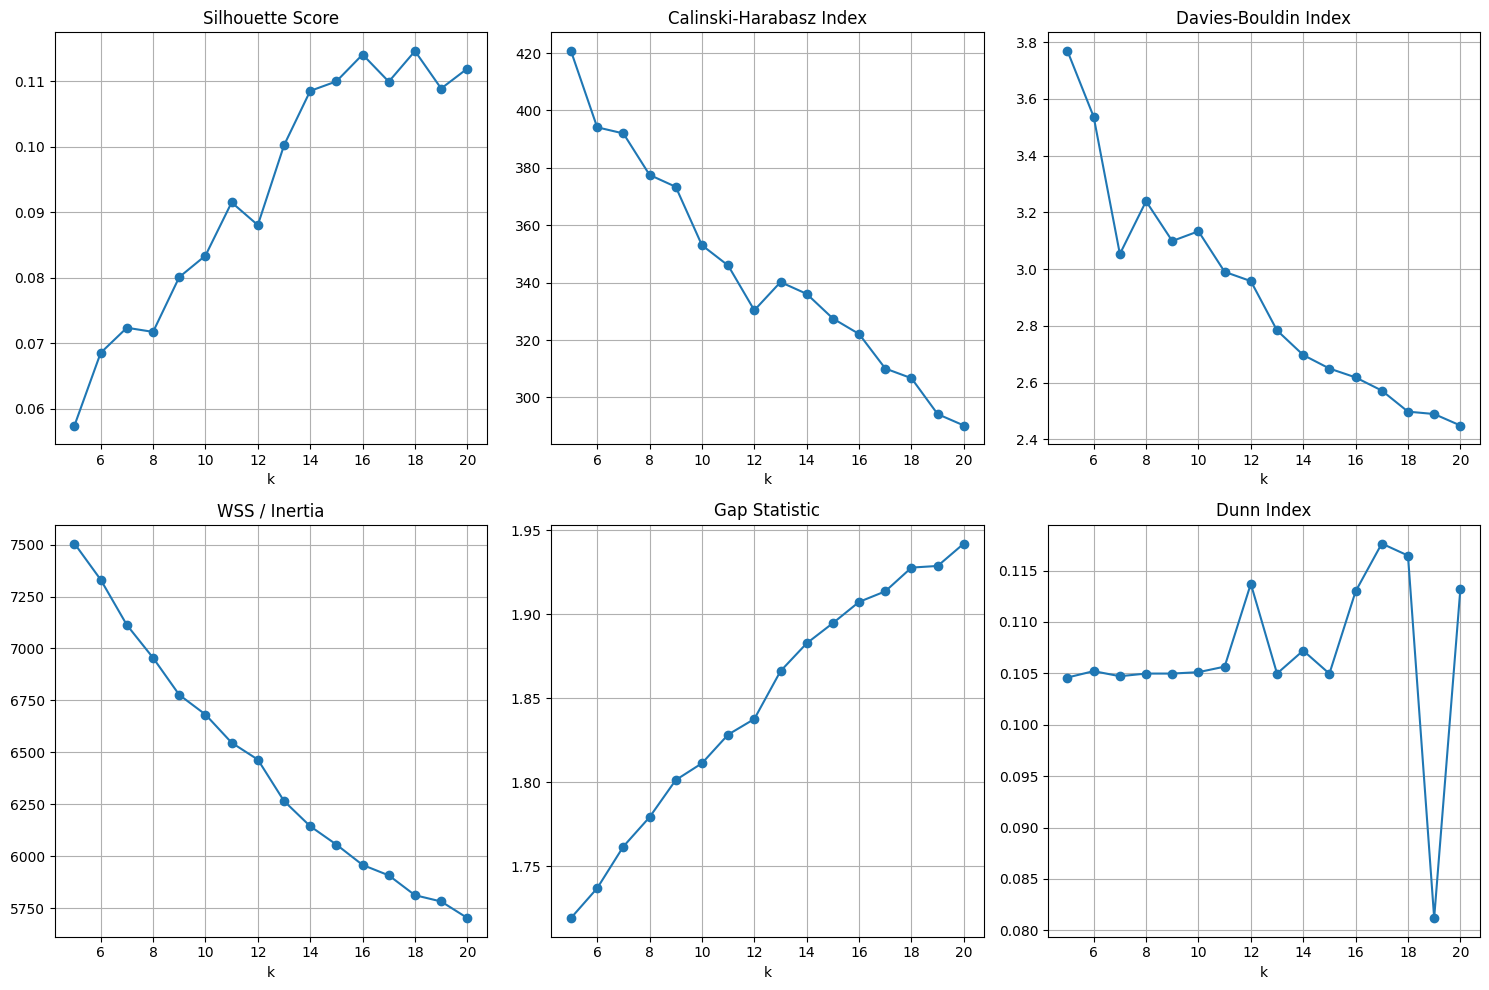

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Silhouette
axes[0, 0].plot(df_metrics['k'], df_metrics['silhouette'], marker='o')
axes[0, 0].set_title('Silhouette Score')
axes[0, 0].set_xlabel('k')
axes[0, 0].grid(True)

# Calinski-Harabasz
axes[0, 1].plot(df_metrics['k'], df_metrics['calinski_harabasz'], marker='o')
axes[0, 1].set_title('Calinski-Harabasz Index')
axes[0, 1].set_xlabel('k')
axes[0, 1].grid(True)

# Davies-Bouldin
axes[0, 2].plot(df_metrics['k'], df_metrics['davies_bouldin'], marker='o')
axes[0, 2].set_title('Davies-Bouldin Index')
axes[0, 2].set_xlabel('k')
axes[0, 2].grid(True)

# WSS/Inertia
axes[1, 0].plot(df_metrics['k'], df_metrics['wss'], marker='o')
axes[1, 0].set_title('WSS / Inertia')
axes[1, 0].set_xlabel('k')
axes[1, 0].grid(True)

# Gap statistic
axes[1, 1].plot(df_metrics['k'], df_metrics['gap'], marker='o')
axes[1, 1].set_title('Gap Statistic')
axes[1, 1].set_xlabel('k')
axes[1, 1].grid(True)

# Dunn Index
axes[1, 2].plot(df_metrics['k'], df_metrics['dunn'], marker='o')
axes[1, 2].set_title('Dunn Index')
axes[1, 2].set_xlabel('k')
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

Таблица метрик

In [8]:
pd.set_option('display.max_columns', None)
df_metrics.style.format({
    'silhouette': '{:.4f}',
    'calinski_harabasz': '{:.2f}',
    'davies_bouldin': '{:.4f}',
    'dunn': '{:.6f}',
    'gap': '{:.6f}',
    'wss': '{:.2f}'
})

,k,silhouette,calinski_harabasz,davies_bouldin,dunn,gap,wss
0,5,0.0575,420.68,3.7687,0.104594,1.719283,7505.17
1,6,0.0685,394.12,3.5369,0.105213,1.737003,7331.27
2,7,0.0724,391.99,3.0531,0.104718,1.761811,7112.97
3,8,0.0717,377.54,3.2393,0.104977,1.779275,6954.95
4,9,0.0801,373.38,3.0990,0.104977,1.801365,6776.72
5,10,0.0834,353.03,3.1334,0.105112,1.811336,6682.03
6,11,0.0915,345.98,2.9904,0.105651,1.828411,6546.25
7,12,0.0880,330.38,2.9577,0.113707,1.837682,6465.07
8,13,0.1002,340.20,2.7838,0.104977,1.866171,6265.57
9,14,0.1085,336.08,2.6971,0.107212,1.882725,6144.21


In [28]:
df_metrics.to_csv("../data/results/metrics/tfidf/tfidf_kmeans_metrics.csv", index=False)

Анализ метрик TF-IDF показывает устойчивый рост качества кластеризации при увеличении k:
silhouette постепенно растtт, Davies-Bouldin снижается, gap и Dunn улучшаются.

Однако после k ≈ 12–14 прирост метрик замедляется, что может указывать на начало
избыточного дробления (over-segmentation) без значимого выигрыша в структуре.

Поэтому для следующего этапа (анализ размеров и интерпретируемости кластеров)
выбираем следующие значения k:

k_candidates = [10, 12, 15, 18, 20]

Они покрывают диапазон от умеренной до более детализированной сегментации,
позволяя оценить баланс между интерпретируемостью и дробностью кластеров.

In [30]:
candidate_ks = [13, 14, 15, 18, 20]

cluster_sizes_report = {}

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_tfidf_norm)
    
    df_temp = df.copy()
    df_temp['cluster'] = labels
    
    report = get_cluster_report(df_temp, 'cluster')
    cluster_sizes_report[k] = report
    
    print(f"\nK = {k}")
    print(f"Размеры кластеров: {report['sizes']}")
    print(f"Минимальный кластер: {report['min_size']} постов")
    print(f"Максимальный кластер: {report['max_size']} постов ({report['max_size_pct']:.1%})")


K = 13
Размеры кластеров: {0: 1198, 1: 808, 2: 822, 3: 668, 4: 592, 5: 431, 6: 758, 7: 1596, 8: 1047, 9: 706, 10: 754, 11: 803, 12: 284}
Минимальный кластер: 284 постов
Максимальный кластер: 1596 постов (15.2%)

K = 14
Размеры кластеров: {0: 823, 1: 811, 2: 802, 3: 663, 4: 547, 5: 433, 6: 748, 7: 1535, 8: 1411, 9: 703, 10: 762, 11: 805, 12: 284, 13: 140}
Минимальный кластер: 140 постов
Максимальный кластер: 1535 постов (14.7%)

K = 15
Размеры кластеров: {0: 816, 1: 690, 2: 698, 3: 654, 4: 540, 5: 418, 6: 731, 7: 1211, 8: 724, 9: 685, 10: 714, 11: 802, 12: 284, 13: 140, 14: 1360}
Минимальный кластер: 140 постов
Максимальный кластер: 1360 постов (13.0%)

K = 18
Размеры кластеров: {0: 457, 1: 272, 2: 690, 3: 466, 4: 524, 5: 400, 6: 580, 7: 1126, 8: 565, 9: 468, 10: 612, 11: 792, 12: 283, 13: 137, 14: 1253, 15: 567, 16: 649, 17: 626}
Минимальный кластер: 137 постов
Максимальный кластер: 1253 постов (12.0%)

K = 20
Размеры кластеров: {0: 279, 1: 248, 2: 199, 3: 461, 4: 518, 5: 404, 6: 575,

In [31]:
summary_data = []

for k in candidate_ks:
    report = cluster_sizes_report[k]
    summary_data.append({
        'k': k,
        'min_cluster': report['min_size'],
        'max_cluster': report['max_size'],
        'max_cluster_pct': f"{report['max_size_pct']:.1%}",
        'n_micro': report['n_micro_clusters'],
        'has_dump': report['has_dump_cluster'],
        'balance': f"{report['balance_ratio']:.3f}"
    })

df_summary = pd.DataFrame(summary_data)
df_summary

,k,min_cluster,max_cluster,max_cluster_pct,n_micro,has_dump,balance
0,13,284,1596,15.2%,0,False,0.178
1,14,140,1535,14.7%,0,False,0.091
2,15,140,1360,13.0%,0,False,0.103
3,18,137,1253,12.0%,0,False,0.109
4,20,136,1267,12.1%,0,False,0.107


C:\Users\enoni\AppData\Local\Temp\ipykernel_39160\4140398638.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend()


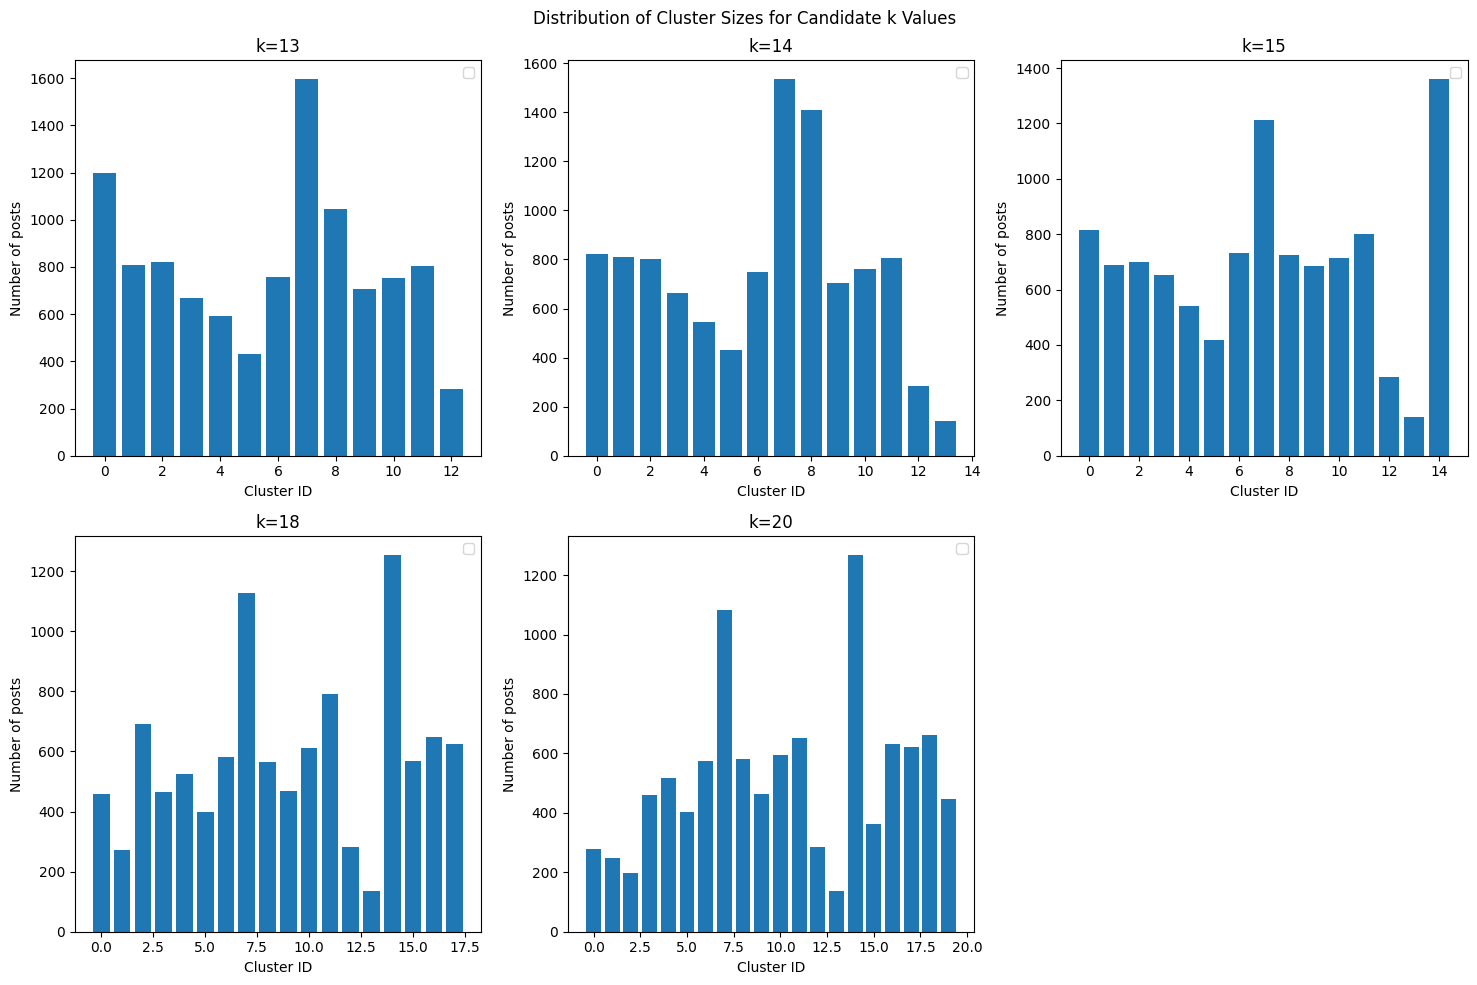

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, k in enumerate(candidate_ks):
    sizes = cluster_sizes_report[k]['sizes']
    axes[idx].bar(range(len(sizes)), list(sizes.values()))
    axes[idx].set_title(f'k={k}')
    axes[idx].set_xlabel('Cluster ID')
    axes[idx].set_ylabel('Number of posts')
    axes[idx].legend()

plt.suptitle('Distribution of Cluster Sizes for Candidate k Values')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

Анализ распределения размеров кластеров показывает, что все рассмотренные
конфигурации формируют относительно устойчивую структуру без выраженных
гигантских кластеров: доля крупнейшего кластера во всех случаях остается
в пределах 12–15% от общего объема датасета.

Для k=10 и k=12 наблюдается наиболее сбалансированное распределение размеров.
Минимальные кластеры остаются достаточно крупными (455–771 постов), что
указывает на отсутствие чрезмерной фрагментации данных.

При увеличении количества кластеров до 15–20 начинается постепенное
дробление структуры: появляются значительно более мелкие группы
(136–140 постов), а баланс заметно снижается. Это может свидетельствовать
о переходе от устойчивых тематических групп к более узким лексическим подтемам.

При этом даже для k=18 и k=20 структура остается относительно стабильной:
микрокластеры (<50 постов) отсутствуют, а гигантских кластеров-свалок не формируется.

С учетом совокупности метрик и распределения размеров наиболее перспективными
кандидатами для дальнейшего семантического анализа являются k=12, k=15 и k=18.
Эти значения обеспечивают различный уровень детализации контента при
сохранении интерпретируемости и устойчивости кластеров.

In [33]:
final_candidates = [12, 13, 14, 15, 18]

Сохранение кластеров для кандидатов (центроидные примеры)

In [ ]:
base_examples_path = "../data/results/candidate_examples/tfidf"
base_clusters_path = "../data/results/final_clusters/tfidf"

os.makedirs(base_examples_path, exist_ok=True)
os.makedirs(base_clusters_path, exist_ok=True)

for k in final_candidates:

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )

    labels = km.fit_predict(X_tfidf_norm)

    df_cluster = df.copy()

    df_cluster['cluster'] = labels

    cluster_sizes = (
        df_cluster['cluster']
        .value_counts()
        .sort_index()
    )

    df_cluster['cluster_size'] = (
        df_cluster['cluster']
        .map(cluster_sizes)
    )

    centroid_examples = get_centroid_examples(
        X_tfidf_norm,
        labels,
        df,
        n_examples=50
    )

    # TXT С ПРИМЕРАМИ

    output_txt = (
        f"{base_examples_path}/tfidf_k{k}_candidate_examples.txt"
    )

    with open(output_txt, "w", encoding="utf-8") as f:

        f.write("=" * 80 + "\n")
        f.write("TF-IDF + KMeans\n")
        f.write(f"k = {k}\n")
        f.write("TOP-50 nearest centroid examples\n")
        f.write("=" * 80 + "\n\n")

        f.write("CLUSTER SIZES:\n\n")

        for cluster_id, size in cluster_sizes.items():

            f.write(
                f"Cluster {cluster_id}: {size} posts\n"
            )

        f.write("\n" + "=" * 80 + "\n\n")

        for cluster_id in sorted(cluster_sizes.index):

            f.write(f"\n{'=' * 80}\n")
            f.write(
                f"CLUSTER {cluster_id} "
                f"({cluster_sizes[cluster_id]} posts)\n"
            )
            f.write(f"{'=' * 80}\n\n")

            examples = centroid_examples.get(cluster_id, {})

            texts = examples.get('texts', [])
            distances = examples.get('distances', [])

            for idx, (text, dist) in enumerate(
                zip(texts, distances)
            ):

                clean_text = ' '.join(
                    str(text)
                    .replace('\n', ' ')
                    .split()
                )

                f.write(
                    f"[{idx+1}] "
                    f"(distance: {dist:.4f})\n"
                )

                f.write(f"{clean_text}\n\n")

    print(f"Сохранен TXT: {output_txt}")


    # CSV
    output_csv = (
        f"{base_clusters_path}/tfidf_k{k}_clusters.csv"
    )

    df_cluster[
        [
            'post_id',
            'channel_username',
            'text',
            'cluster',
            'cluster_size'
        ]
    ].to_csv(
        output_csv,
        index=False
    )

    print(f"Сохранен CSV: {output_csv}")

print("Все кандидаты сохранены.")

Сохранен TXT: ../data/results/candidate_examples/tfidf/tfidf_k12_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/tfidf/tfidf_k12_clusters.csv
Сохранен TXT: ../data/results/candidate_examples/tfidf/tfidf_k15_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/tfidf/tfidf_k15_clusters.csv
Сохранен TXT: ../data/results/candidate_examples/tfidf/tfidf_k18_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/tfidf/tfidf_k18_clusters.csv
Все кандидаты сохранены.


В процессе анализа было добавлено еще два кандидата на k: 13 и 14. Результаты такие:

при k = 12 кластеризация выделяет крупные темы (Apple, AI-бенчмарки, образование, игры), но страдает из-за двух больших «мусорных» кластеров, где смешаны IT-политика, бытовые новости и философские эссе - анализ получается грубым.

при k = 13 качество растет: начинает выделяться регулирование Рунета, но остается один размытый кластер.

k = 14 дает оптимальный баланс: добавляется чистый кластер «опросы», все ключевые темы сохраняются, интерпретируемость высокая.

при k = 15 новых смыслов не возникает. Просто перенумерация.

при k = 18 максимальная детализация (микрониши в Apple и AI), но появляются очень маленькие шумовые кластеры, а один «мусорный» кластер (личные эссе, философия) так и не распадается.

Таким образом, выбираем финального кандидата: k=14

In [13]:
FINAL_K_TFIDF = 14

Выполняем финальную кластеризацию, создаем итоговый датафрейм

In [14]:
km_final = KMeans(
    n_clusters=FINAL_K_TFIDF,
    random_state=RANDOM_STATE,
    n_init='auto'
)

labels = km_final.fit_predict(X_tfidf_norm)

df_cluster_final = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_cluster_final['cluster_tfidf'] = labels

cluster_sizes = (
    df_cluster_final['cluster_tfidf']
    .value_counts()
    .sort_index()
)

df_cluster_final['cluster_tfidf_size'] = (
    df_cluster_final['cluster_tfidf']
    .map(cluster_sizes)
)


Названия кластеров на основе ручного анализа

In [34]:
cluster_names_tfidf = {
    0: "Apple: слухи и релизы",
    1: "Тренды ИИ: OpenAI, DeepSeek, Gemini",
    2: "IT-образование: стажировки и курсы",
    3: "Наука и ИИ: Сколтех, инженерия",
    4: "Telegram: блокчейн, TON, криптоновости",
    5: "Игры: анонсы, трейлеры, релизы",
    6: "Новости: глобальные AI-дайджесты",
    7: "Прочее: личное, финансы, космос, лайфхаки",
    8: "Регулирование: блокировки, законы, ФСБ, РКН",
    9: "Наука и ИИ: исследования, лекции, материалы",
    10: "ИИ-инструменты: генерация, промптинг",
    11: "Университет: официальные новости СПбГУ",
    12: "Новости: короткие дайджесты дня",
    13: "Интерактив: опросы и голосования"
}

Добавляем названия в датафрейм

In [35]:
df_cluster_final['cluster_tfidf_name'] = (
    df_cluster_final['cluster_tfidf']
    .map(cluster_names_tfidf)
)

In [36]:
distribution = (
    df_cluster_final[
        [
            'cluster_tfidf',
            'cluster_tfidf_name',
            'cluster_tfidf_size'
        ]
    ]
    .drop_duplicates()
    .sort_values('cluster_tfidf')
)

distribution

,cluster_tfidf,cluster_tfidf_name,cluster_tfidf_size
731,0,Apple: слухи и релизы,823
339,1,"Тренды ИИ: OpenAI, DeepSeek, Gemini",811
4,2,IT-образование: стажировки и курсы,802
0,3,"Наука и ИИ: Сколтех, инженерия",663
760,4,"Telegram: блокчейн, TON, криптоновости",547
484,5,"Игры: анонсы, трейлеры, релизы",433
36,6,Новости: глобальные AI-дайджесты,748
18,7,"Прочее: личное, финансы, космос, лайфхаки",1535
67,8,"Регулирование: блокировки, законы, ФСБ, РКН",1411
24,9,"Наука и ИИ: исследования, лекции, материалы",703


Сохраняем примеры финальной кластеризации

In [37]:
os.makedirs(
    "../data/results/final_examples/tfidf",
    exist_ok=True
)

output_path = (
    "../data/results/final_examples/"
    "tfidf/tfidf_final_examples.txt"
)

# Получаем примеры, ближайшие к центроиду 
centroid_examples = get_centroid_examples(
    X_tfidf_norm, 
    labels, 
    df, 
    n_examples=50
)

# Сохраняем
with open(output_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("TF-IDF + KMeans ФИНАЛЬНАЯ кластеризация\n")
    f.write(f"k = {FINAL_K_TFIDF}\n")
    f.write("Метод отбора: 50 постов, ближайших к центроиду каждого кластера\n")
    f.write("=" * 80 + "\n\n")
    
    # Информация о размерах
    f.write("РАЗМЕРЫ КЛАСТЕРОВ:\n\n")
    for cluster_id in sorted(df_cluster_final['cluster_tfidf'].unique()):
        size = cluster_sizes[cluster_id]
        name = cluster_names_tfidf[cluster_id]
        f.write(f"Cluster {cluster_id} ({name}): {size} постов\n")
    
    f.write("\n" + "=" * 80 + "\n\n")
    
    # Примеры из каждого кластера
    for cluster_id in sorted(df_cluster_final['cluster_tfidf'].unique()):
        f.write(f"\n{'='*80}\n")
        f.write(f"CLUSTER {cluster_id}: {cluster_names_tfidf[cluster_id]}\n")
        f.write(f"Всего постов: {cluster_sizes[cluster_id]}\n")
        f.write(f"{'='*80}\n\n")
        f.write("ТОП-50 ПОСТОВ, БЛИЖАЙШИХ К ЦЕНТРОИДУ:\n\n")
        
        examples = centroid_examples.get(cluster_id, {})
        texts = examples.get('texts', [])
        distances = examples.get('distances', [])
        
        for idx, (text, dist) in enumerate(zip(texts, distances)):
            clean_text = ' '.join(str(text).replace('\n', ' ').split())
            f.write(f"[{idx+1}] (distance: {dist:.4f})\n")
            f.write(f"{clean_text}\n\n")
    
    # Добавляем также случайные примеры для проверки разнообразия
    f.write("\n" + "="*80 + "\n")
    f.write("ДОПОЛНИТЕЛЬНО: СЛУЧАЙНЫЕ ПРИМЕРЫ (по 20 на кластер)\n")
    f.write("="*80 + "\n\n")
    
    for cluster_id in sorted(df_cluster_final['cluster_tfidf'].unique()):
        f.write(f"\n{'='*80}\n")
        f.write(f"CLUSTER {cluster_id}: {cluster_names_tfidf[cluster_id]}\n")
        f.write(f"{'='*80}\n\n")
        
        cluster_texts = df_cluster_final[df_cluster_final['cluster_tfidf'] == cluster_id]['text'].tolist()
        random_indices = np.random.choice(len(cluster_texts), size=min(20, len(cluster_texts)), replace=False)
        
        for idx, text_idx in enumerate(random_indices):
            clean_text = ' '.join(str(cluster_texts[text_idx]).replace('\n', ' ').split())
            f.write(f"[СЛУЧАЙНЫЙ {idx+1}]\n")
            f.write(f"{clean_text}\n\n")

print(f"Сохранен: {output_path}")

Сохранен: ../data/results/final_examples/tfidf/tfidf_final_examples.txt


Сохраняем итоговый датафрейм

In [38]:
os.makedirs(
    "../data/results/final_clusters/tfidf",
    exist_ok=True
)

df_cluster_final.to_csv(
    "../data/results/final_clusters/"
    "tfidf/tfidf_final_clusters.csv",
    index=False
)
print("Статистика по tfidf_cluster:\n")
df_cluster_final['cluster_tfidf_name'].value_counts().to_string()

Статистика по tfidf_cluster:



'cluster_tfidf_name\nПрочее: личное, финансы, космос, лайфхаки      1535\nРегулирование: блокировки, законы, ФСБ, РКН    1411\nApple: слухи и релизы                           823\nТренды ИИ: OpenAI, DeepSeek, Gemini             811\nУниверситет: официальные новости СПбГУ          805\nIT-образование: стажировки и курсы              802\nИИ-инструменты: генерация, промптинг            762\nНовости: глобальные AI-дайджесты                748\nНаука и ИИ: исследования, лекции, материалы     703\nНаука и ИИ: Сколтех, инженерия                  663\nTelegram: блокчейн, TON, криптоновости          547\nИгры: анонсы, трейлеры, релизы                  433\nНовости: короткие дайджесты дня                 284\nИнтерактив: опросы и голосования                140'

c:\Users\enoni\PycharmProjects\ai_channels_feature_engineering\emb_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


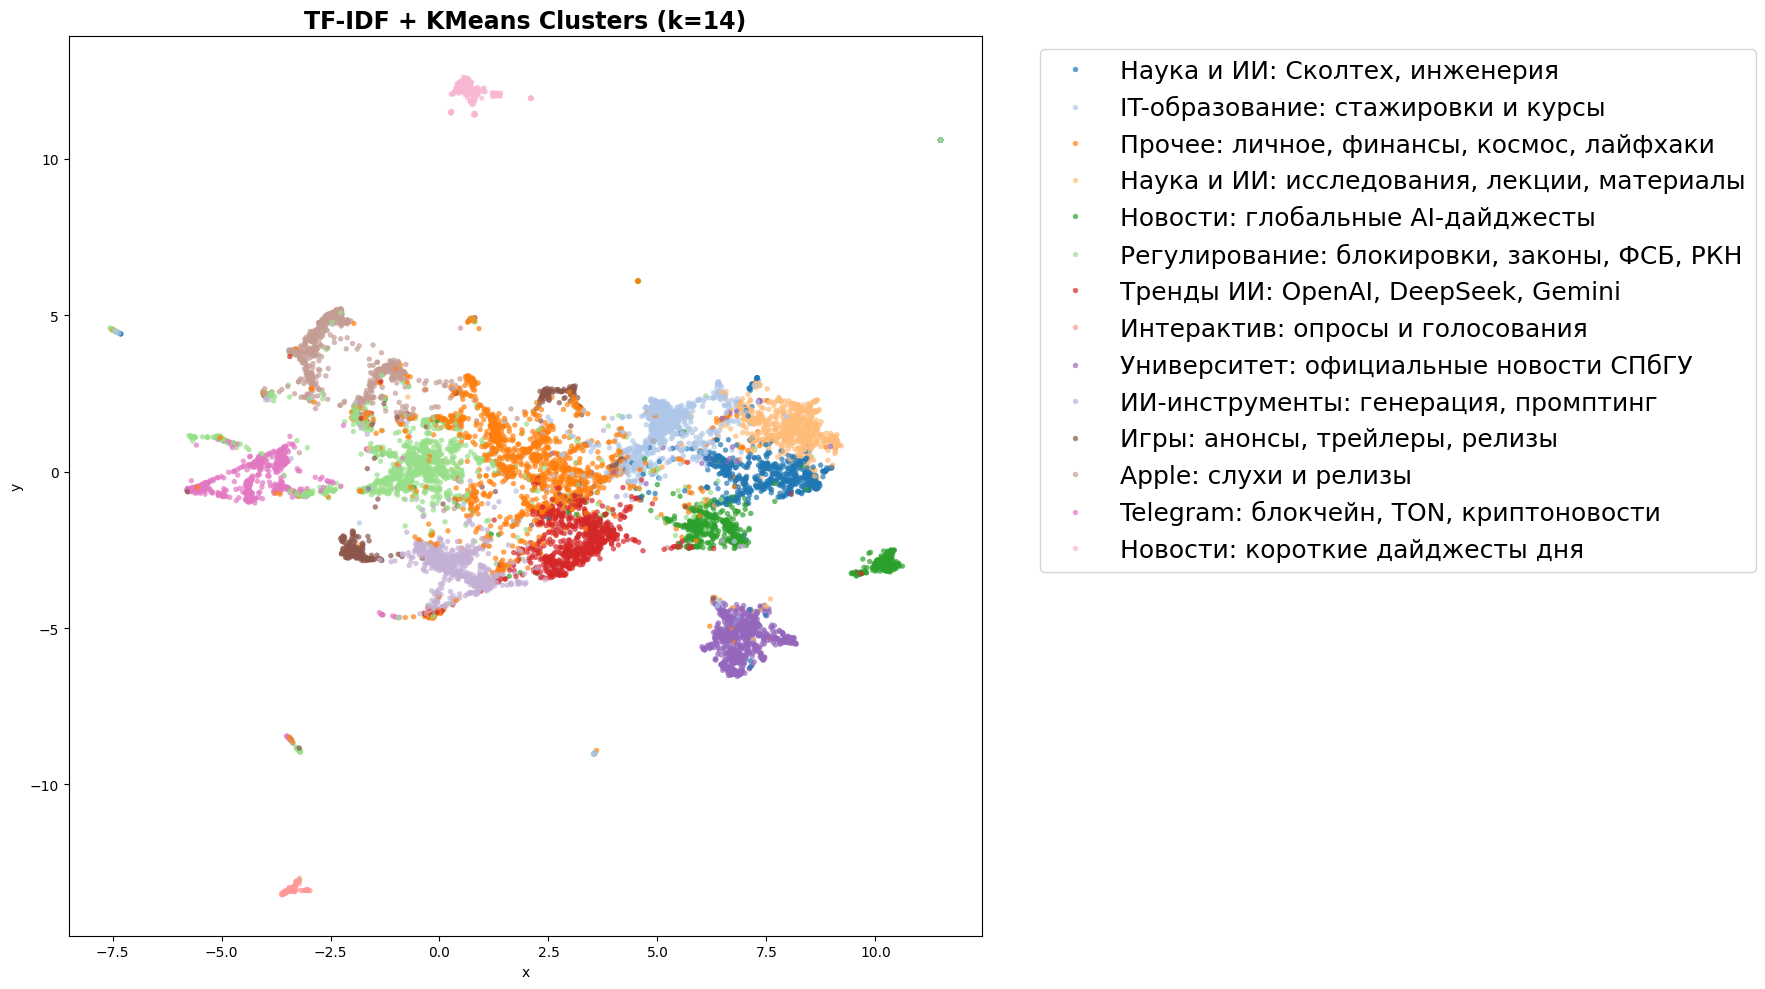

In [39]:
import umap.umap_ as umap

umap_reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=15, 
    min_dist=0.1, 
    metric='cosine', 
    random_state=RANDOM_STATE
)
X_umap = umap_reducer.fit_transform(X_tfidf_norm)

plot_df = pd.DataFrame({
    'x': X_umap[:, 0],
    'y': X_umap[:, 1],
    'cluster_name': df_cluster_final['cluster_tfidf_name']
})

plt.figure(figsize=(18, 10))
scatter = sns.scatterplot(
    data=plot_df,
    x='x', 
    y='y', 
    hue='cluster_name',
    palette='tab20',
    s=15, 
    alpha=0.7, 
    linewidth=0
)

plt.title('TF-IDF + KMeans Clusters (k=14)', fontsize=17, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)
plt.tight_layout()

os.makedirs(
    "../data/plots/tfidf/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/tfidf/kmeans/"
    "tfidf_kmeans_umap_final.png",
    dpi=200,
    bbox_inches='tight'
)
plt.show()

# HDBSCAN

In [ ]:
import hdbscan

from hdbscan.validity import validity_index

from sklearn.metrics import (
    silhouette_score
)

from tqdm import tqdm

Grid Search для tf-idf hdbscan

In [ ]:
import warnings

warnings.filterwarnings("ignore")

min_cluster_sizes = [
    10,
    20,
    30,
    50,
    80,
    100,
    150
]

min_samples_list = [
    1,
    2,
    5,
    10
]

results_hdbscan = []


for mcs in tqdm(min_cluster_sizes):

    for ms in min_samples_list:

        model = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='eom',
            prediction_data=True,
            core_dist_n_jobs=-1
        )

        labels = model.fit_predict(
            X_tfidf_norm
        )

        n_clusters = len(
            set(labels)
        ) - (1 if -1 in labels else 0)

        n_noise = np.sum(labels == -1)

        noise_ratio = (
            n_noise / len(labels)
        )

        sil = np.nan
        dbcv = np.nan

        valid_mask = labels != -1

        unique_valid = np.unique(
            labels[valid_mask]
        )

        # silhouette только если >=2 кластера
        if len(unique_valid) >= 2:

            sil = silhouette_score(
                X_tfidf_norm[valid_mask],
                labels[valid_mask]
            )

        # DBCV
        try:

            dbcv = validity_index(
                X_tfidf_norm,
                labels
            )

        except:

            dbcv = np.nan

        results_hdbscan.append({

            'min_cluster_size': mcs,
            'min_samples': ms,

            'n_clusters': n_clusters,

            'noise_ratio': noise_ratio,

            'silhouette': sil,

            'dbcv': dbcv
        })

100%|██████████| 7/7 [2:20:35<00:00, 1205.02s/it]


Результаты

In [ ]:
df_hdbscan = pd.DataFrame(
    results_hdbscan
)

df_hdbscan.head(10)

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,dbcv
0,10,1,66,0.627018,0.242613,0.018573
1,10,2,54,0.672781,0.292438,0.039600
2,10,5,38,0.721028,0.362640,0.048836
3,10,10,32,0.728767,0.372207,0.054827
4,20,1,39,0.622528,0.268432,0.021479
5,20,2,36,0.668769,0.309193,0.032748
6,20,5,28,0.711761,0.374826,0.054459
7,20,10,3,0.230343,0.063537,-0.043612
8,30,1,30,0.621859,0.277273,0.020546
9,30,2,27,0.674787,0.324074,0.035045


Сортировка лучших конфигураций

In [ ]:
df_hdbscan_filtered = df_hdbscan[
    (df_hdbscan['n_clusters'] >= 5) &
    (df_hdbscan['n_clusters'] <= 20)

].sort_values(
    ['dbcv', 'silhouette'],
    ascending=False

)

df_hdbscan_filtered.reset_index(drop=True)

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,dbcv
0,150,10,6,0.600841,0.158024,0.062788
1,150,5,6,0.564823,0.152413,-0.012567


Сохранение метрик

In [ ]:
os.makedirs(
    "../data/results/metrics/tfidf",
    exist_ok=True
)

df_hdbscan.to_csv(
    "../data/results/metrics/tfidf/"
    "tfidf_hdbscan_grid_search_metrics.csv",
    index=False
)

df_hdbscan_filtered.to_csv(
    "../data/results/metrics/tfidf/"
    "tfidf_hdbscan_filtered_metrics.csv",
    index=False
)

Визуализация

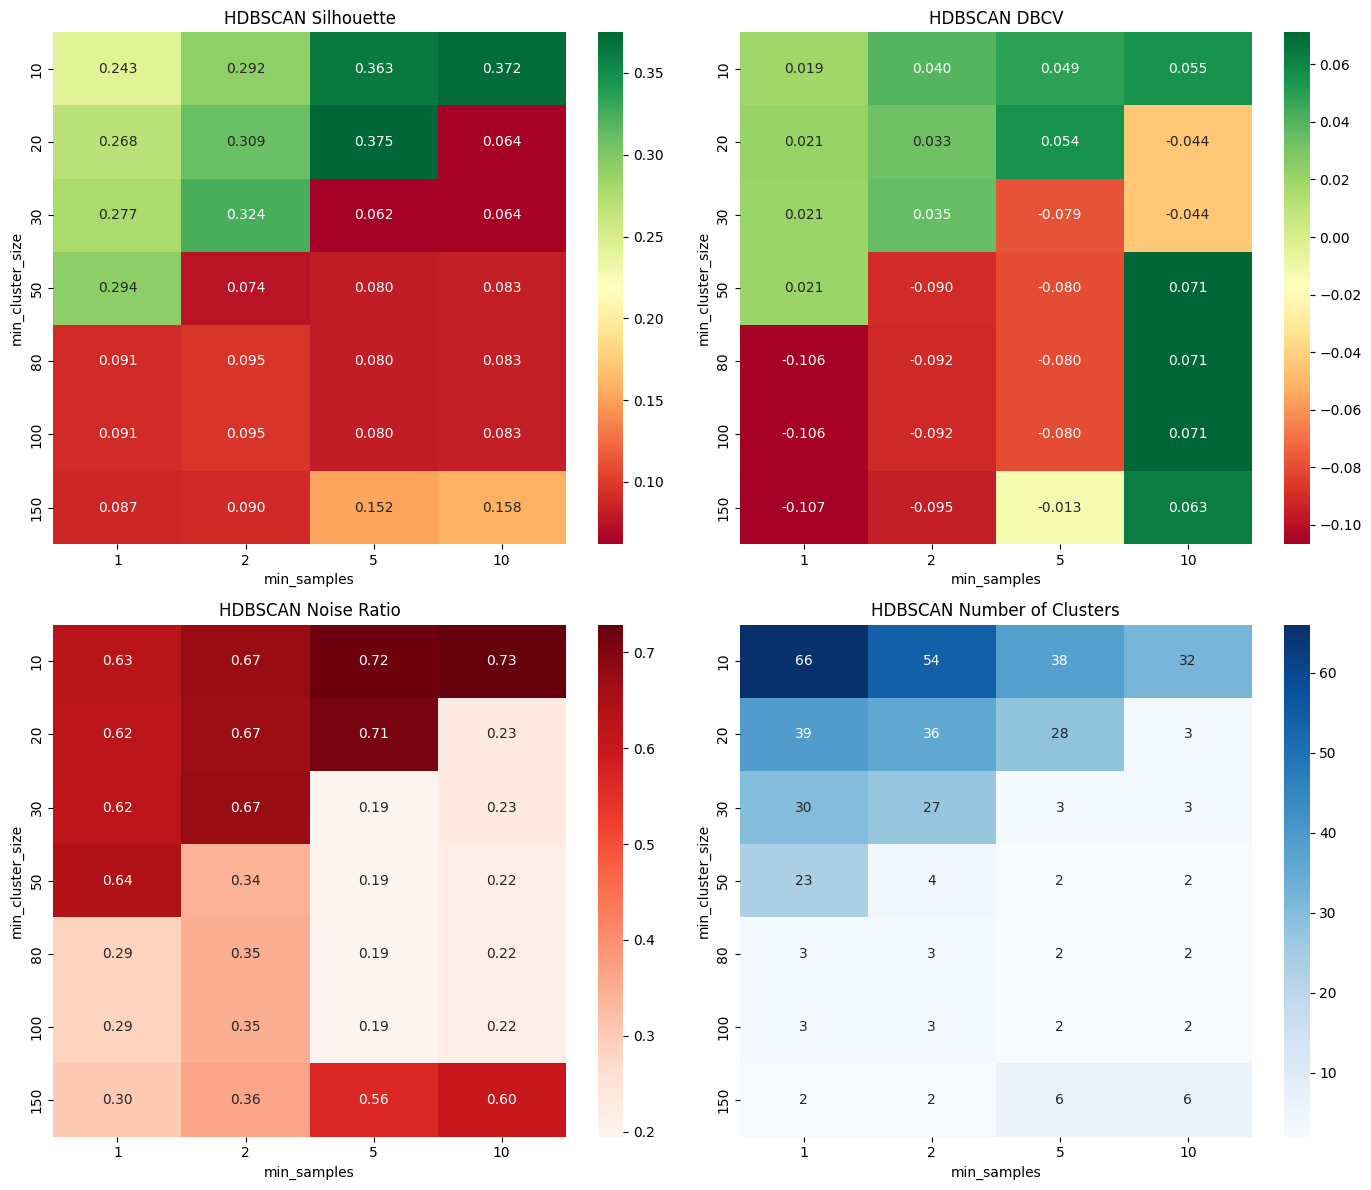

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# HDBSCAN Silhouette
pivot_sil = df_hdbscan.pivot_table(
    values='silhouette',
    index='min_cluster_size',
    columns='min_samples'
)
sns.heatmap(
    pivot_sil,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    ax=axes[0, 0]
)
axes[0, 0].set_title('HDBSCAN Silhouette')

# HDBSCAN DBCV
pivot_dbcv = df_hdbscan.pivot_table(
    values='dbcv',
    index='min_cluster_size',
    columns='min_samples'
)
sns.heatmap(
    pivot_dbcv,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    ax=axes[0, 1]
)
axes[0, 1].set_title('HDBSCAN DBCV')

# HDBSCAN Noise Ratio
pivot_noise = df_hdbscan.pivot_table(
    values='noise_ratio',
    index='min_cluster_size',
    columns='min_samples'
)
sns.heatmap(
    pivot_noise,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    ax=axes[1, 0]
)
axes[1, 0].set_title('HDBSCAN Noise Ratio')

# HDBSCAN Number of Clusters
pivot_clusters = df_hdbscan.pivot_table(
    values='n_clusters',
    index='min_cluster_size',
    columns='min_samples'
)
sns.heatmap(
    pivot_clusters,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    ax=axes[1, 1]
)
axes[1, 1].set_title('HDBSCAN Number of Clusters')

plt.tight_layout()

os.makedirs(
    "../data/plots/tfidf/hdbscan",
    exist_ok=True
)

plt.savefig(
    "../data/plots/tfidf/hdbscan/"
    "tfidf_hdbscan_heat_map.png",
    dpi=200,
    bbox_inches='tight'
)
plt.show()

Результаты HDBSCAN показывают, что алгоритм испытывает сложности
с выделением устойчивой плотностной структуры в TF-IDF пространстве.

Конфигурации с наилучшими значениями DBCV формируют всего 2–6 кластеров,
что недостаточно для задач содержательного анализа типов контента.

При попытке получить большее количество кластеров резко возрастает
доля шума, достигающая 70% и более. Это указывает на высокую
разреженность TF-IDF пространства и отсутствие выраженных плотностных
областей для большинства постов.

Кроме того, большое количество кластеров сопровождается сильной
фрагментацией и нестабильностью структуры.

Таким образом, HDBSCAN в рамках TF-IDF представления показывает
значительно менее устойчивые результаты по сравнению с KMeans и
рассматривается скорее как дополнительный эксперимент, а не как
основной метод кластеризации.

Посмотрим на конфигурацию, которая выдает 6 кластеров:

In [ ]:
hdbscan_final = hdbscan.HDBSCAN(

    min_cluster_size=150,
    min_samples=5,

    metric='euclidean',

    cluster_selection_method='eom',

    prediction_data=True,

    core_dist_n_jobs=-1
)

labels_hdbscan = hdbscan_final.fit_predict(
    X_tfidf_norm
)

In [ ]:
df_hdbscan_clusters = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_hdbscan_clusters['cluster_hdbscan'] = (
    labels_hdbscan
)

cluster_sizes_hdbscan = (
    df_hdbscan_clusters['cluster_hdbscan']
    .value_counts()
    .sort_index()
)

df_hdbscan_clusters['cluster_size'] = (
    df_hdbscan_clusters['cluster_hdbscan']
    .map(cluster_sizes_hdbscan)
)

print(
    df_hdbscan_clusters[
        'cluster_hdbscan'
    ].value_counts()
)

cluster_hdbscan
-1    5912
 1    2953
 3     490
 5     425
 0     268
 4     216
 2     203
Name: count, dtype: int64


Данная конфигурация HDBSCAN сформировала 6 кластеров,
при этом значительная часть постов была отнесена к шуму.

Наиболее крупный кластер содержал 2953 поста, тогда как
остальные группы оказались существенно меньше и менее устойчивыми.
Подобная структура указывает на наличие одного широкого
слаборазделимого тематического региона и большого количества
объектов, не формирующих плотные локальные области.

Полученные результаты дополнительно подтверждают, что
TF-IDF пространство для данного датасета обладает высокой
разреженностью и плохо подходит для данного метода кластеризации

Посмотрим на примеры кластеров

In [ ]:
non_noise_mask = labels_hdbscan != -1

centroid_examples = get_centroid_examples(
    X_tfidf_norm[non_noise_mask],
    labels_hdbscan[non_noise_mask],
    df[non_noise_mask].reset_index(drop=True),
    n_examples=30
)

output_path = (
    "../data/results/final_examples/"
    "tfidf/tfidf_hdbscan_examples.txt"
)

with open(output_path, "w", encoding="utf-8") as f:

    f.write("=" * 80 + "\n")
    f.write("TF-IDF + HDBSCAN\n")
    f.write("=" * 80 + "\n\n")

    cluster_sizes = (
        pd.Series(labels_hdbscan)
        .value_counts()
        .sort_index()
    )

    f.write("CLUSTER SIZES:\n\n")

    for cluster_id, size in cluster_sizes.items():

        f.write(
            f"Cluster {cluster_id}: "
            f"{size} posts\n"
        )

    f.write("\n" + "=" * 80 + "\n\n")

    for cluster_id in sorted(centroid_examples.keys()):

        f.write(f"\n{'='*80}\n")

        f.write(
            f"CLUSTER {cluster_id}\n"
        )

        f.write(f"{'='*80}\n\n")

        texts = centroid_examples[
            cluster_id
        ]['texts']

        distances = centroid_examples[
            cluster_id
        ]['distances']

        for idx, (text, dist) in enumerate(
            zip(texts, distances)
        ):

            clean_text = ' '.join(
                str(text)
                .replace('\n', ' ')
                .split()
            )

            f.write(
                f"[{idx+1}] "
                f"(distance: {dist:.4f})\n"
            )

            f.write(f"{clean_text}\n\n")

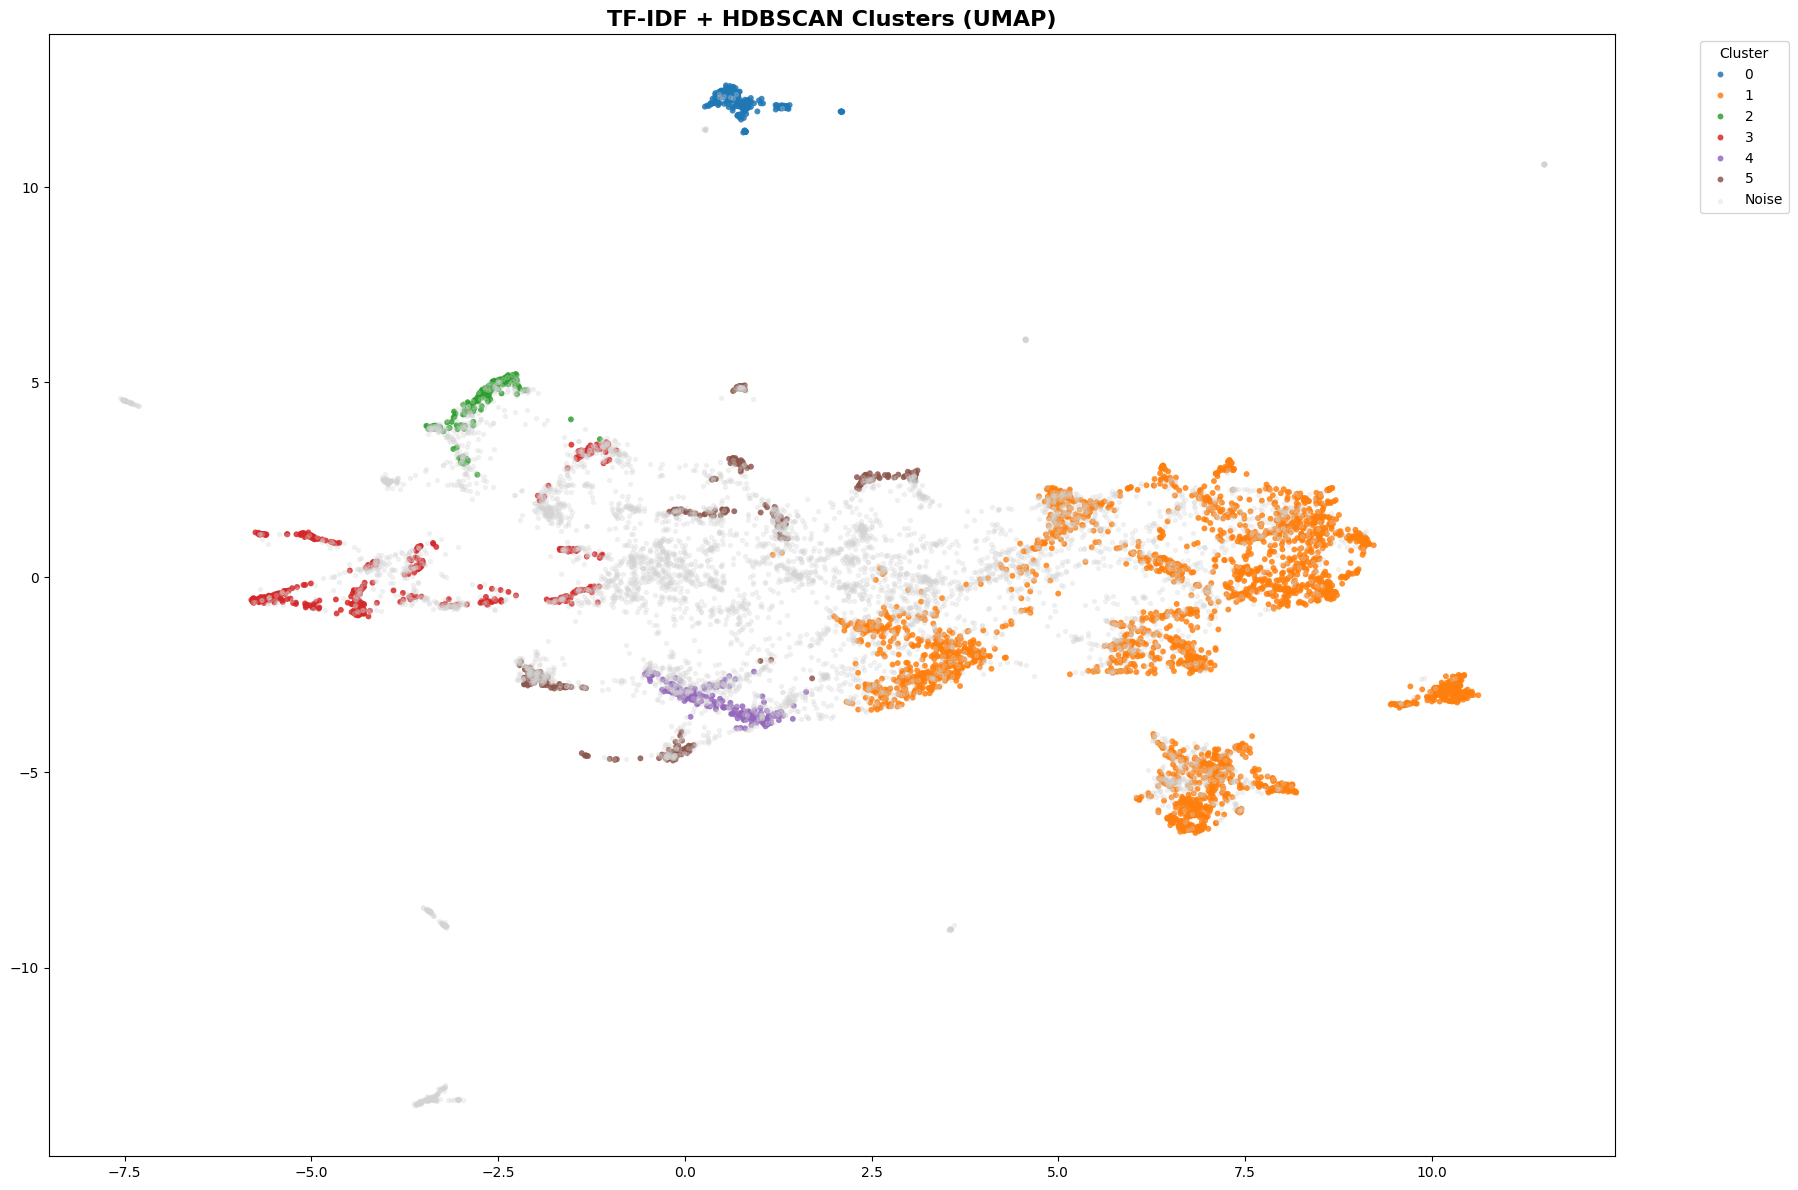

In [ ]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap_hdbscan = umap_reducer.fit_transform(
    X_tfidf_norm
)


plt.figure(figsize=(18, 12))


mask_clusters = labels_hdbscan != -1
sns.scatterplot(
    x=X_umap_hdbscan[mask_clusters, 0],
    y=X_umap_hdbscan[mask_clusters, 1],
    hue=labels_hdbscan[mask_clusters],
    palette='tab10',
    s=18,
    alpha=0.85,
    linewidth=0
)


mask_noise = labels_hdbscan == -1
plt.scatter(
    X_umap_hdbscan[mask_noise, 0],
    X_umap_hdbscan[mask_noise, 1],
    c='lightgray',
    s=8,
    alpha=0.25,
    label='Noise'
)


plt.title(
    'TF-IDF + HDBSCAN Clusters (UMAP)',
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()



os.makedirs(
    "../data/plots/tfidf/hdbscan",
    exist_ok=True
)

output_path = (
    "../data/plots/tfidf/hdbscan/"
    "tfidf_hdbscan_umap.png"
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

HDBSCAN продемонстрировал иной подход к кластеризации по сравнению с KMeans:
алгоритм выделял только наиболее плотные и устойчивые тематические группы,
маркируя остальную часть данных как шум.

В результате были получены несколько кластеров
(например, AI-инструменты, Apple, Telegram-криптоэкосистема),
однако значительная часть постов не вошла ни в один кластер.

Таким образом, HDBSCAN оказался полезен для поиска наиболее выраженных
тематических центров, но менее эффективен для полной сегментации
всего контента. Для итоговой кластеризации был выбран KMeans,
обеспечивший более полное и интерпретируемое покрытие датасета.